In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import IPython.display
import dataclasses
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
import scipy.stats
import astropy.units as u
import astropy.visualization
import named_arrays as na
import optika
import iris
import ctis
import esis

In [3]:
%%time
scene = esis.flights.f1.data.synth.scene_iris(
    time_start="2014-07-04 11:40",
    velocity_max=150 * u.km / u.s,
)

CPU times: user 3min 33s, sys: 375 ms, total: 3min 34s
Wall time: 28.2 s


In [4]:
scene.inputs.position = scene.inputs.position - scene.inputs.position.mean()

In [5]:
scene = scene[{scene.axis_time: 0}]
scene.timedelta = scene.timedelta[{scene.axis_time: 0}]

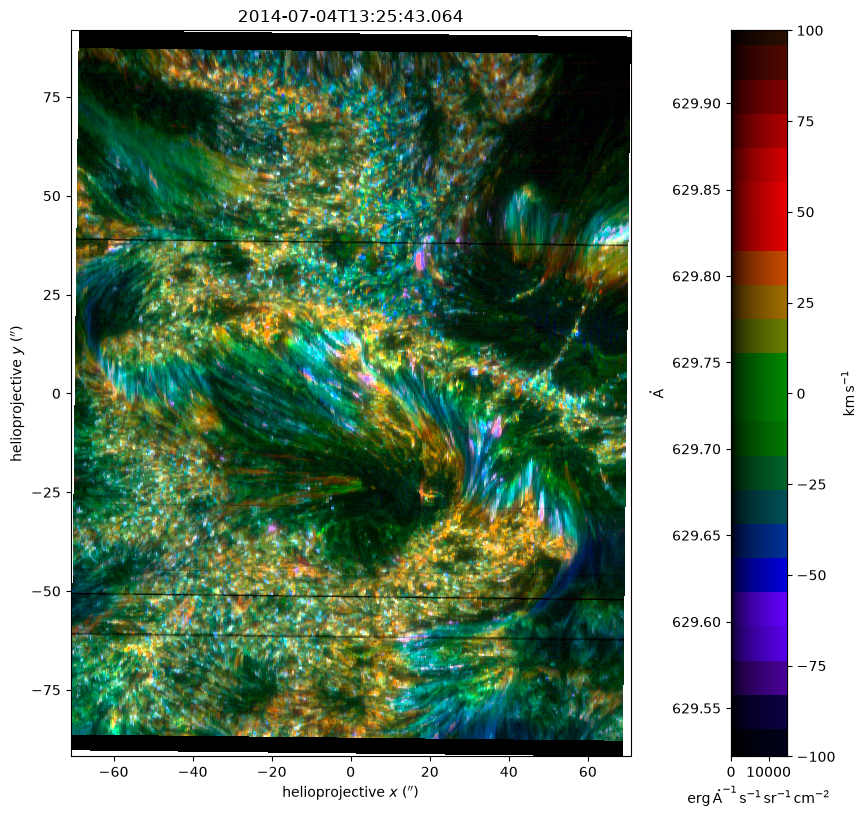

In [6]:
scene.show();

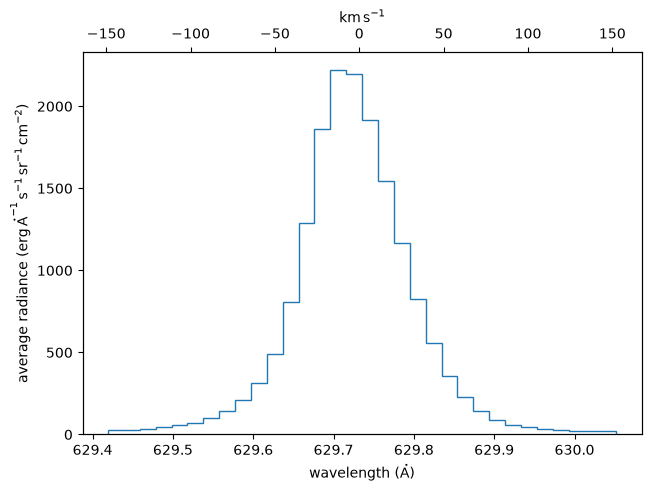

In [7]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    ax_twin = ax.twiny()
    na.plt.stairs(
        scene.inputs.wavelength,
        scene.outputs.mean((scene.axis_detector_x, scene.axis_detector_y)),
        ax=ax,
        label="original",
        axis=scene.axis_wavelength,
    )
    na.plt.stairs(
        scene.inputs.velocity,
        scene.outputs.mean((scene.axis_detector_x, scene.axis_detector_y)),
        ax=ax_twin,
        label="original",
        axis=scene.axis_wavelength,
        linestyle="none",
    )
    ax.set_xlabel(f"wavelength ({ax.get_xlabel()})")
    ax.set_ylabel(f"average radiance ({ax.get_ylabel()})");

In [8]:
wavelength_rest = scene.inputs.wavelength_rest

In [9]:
AA = dict(unit=u.AA, equivalencies=u.doppler_optical(wavelength_rest))

In [10]:
coordinates_scene = scene.inputs

In [11]:
position_sensor = na.Cartesian2dVectorArray(
    x=na.arange(0, 300 + 1, axis="sensor_x") * u.pix,
    y=na.arange(0, 300 + 1, axis="sensor_y") * u.pix,
)

In [12]:
coordinates_sensor = na.SpectralPositionalVectorArray(
    wavelength=scene.inputs.wavelength,
    position=position_sensor,
)

In [13]:
angle = na.linspace(0, 180, num=4, axis="channel", endpoint=False) * u.deg
angle = angle + 0.4 * u.rad
angle.ndarray

<Quantity [ 22.91831181,  67.91831181, 112.91831181, 157.91831181] deg>

In [14]:
channel = "dispersion angle = " + angle.to_string_array("%03d")

In [15]:
ccd = optika.sensors.materials.e2v_ccd97()
absorbance = ccd.absorbance(
    wavelength=wavelength_rest,
    normal=na.Cartesian3dVectorArray(0, 0, -1),
).average
area_effective = 4 * u.mm ** 2 / 0.39 * absorbance.ndarray
area_effective

<Quantity 5.58999892 mm2>

In [16]:
axis_channel = "channel"

In [17]:
instrument = ctis.instruments.IdealInstrument(
    area_effective=area_effective,
    timedelta_exposure=10 * u.s,
    plate_scale=0.77 * u.arcsec / u.pix,
    dispersion=((17.5 * u.km / u.s).to(**AA) - wavelength_rest) / u.pix,
    angle=angle,
    wavelength_ref=wavelength_rest,
    position_ref=na.Cartesian2dVectorArray(150, 150) * u.pix,
    coordinates_scene=coordinates_scene,
    coordinates_sensor=coordinates_sensor,
    channel=channel,
    axis_channel=axis_channel,
    axis_wavelength=scene.axis_wavelength,
    axis_scene_xy=(scene.axis_detector_x, scene.axis_detector_y),
    axis_sensor_xy=("sensor_x", "sensor_y"),
)

In [18]:
%%time
images = instrument.image(scene)

CPU times: user 5min 39s, sys: 3.33 s, total: 5min 43s
Wall time: 1min 41s


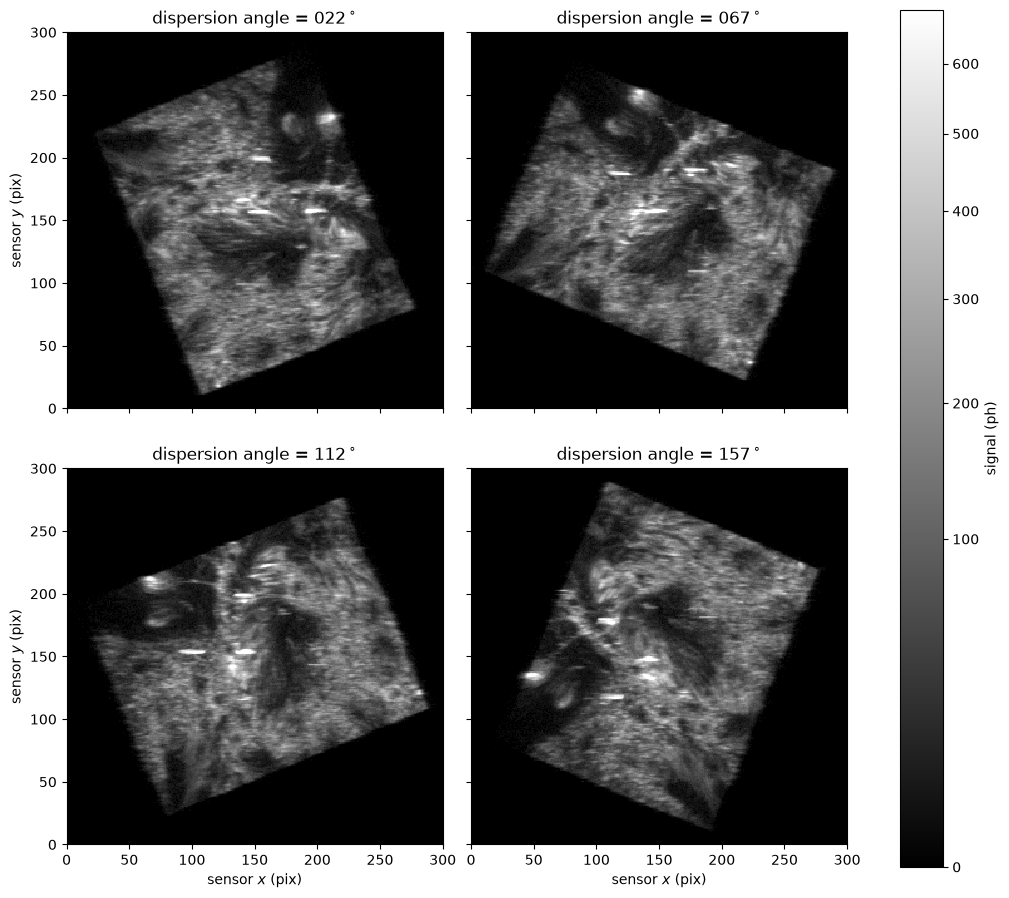

In [19]:
with astropy.visualization.quantity_support():
    fig, axs = na.plt.subplots(
        axis_rows="rows",
        axis_cols="cols",
        nrows=2,
        ncols=2,
        constrained_layout=True,
        figsize=(10,9),
        sharex=True,
        sharey=True,
        origin="upper",
    )
    ax = axs.combine_axes(("rows", "cols"), axis_channel)
    norm = matplotlib.colors.PowerNorm(
        gamma=0.5,
        vmin=0,
        vmax=images.outputs.value.percentile(99.9).ndarray,
    )
    colorizer = plt.Colorizer(
        cmap="gray",
        norm=norm,
    )
    img = na.plt.pcolormesh(
        # channel,
        images.inputs.position.x,
        images.inputs.position.y,
        C=images.outputs.value,
        ax=ax,
        colorizer=colorizer,
    )
    plt.colorbar(
        mappable=plt.cm.ScalarMappable(colorizer=colorizer),
        ax=ax.ndarray,
        label=f"signal ({images.outputs.unit:latex_inline})",
    )
    na.plt.set_title(channel, ax=ax)
    na.plt.set_aspect("equal", ax=ax)
    na.plt.set_xlabel(f"sensor $x$ ({images.inputs.position.x.unit})", ax=axs[dict(rows=~0)])
    na.plt.set_ylabel(f"sensor $y$ ({images.inputs.position.y.unit})", ax=axs[dict(cols=0)])

In [20]:
%%time
image_separated = instrument.image(scene, integrate=False, noise=False)

CPU times: user 9.42 s, sys: 96.9 ms, total: 9.51 s
Wall time: 1.67 s


In [21]:
%%time
backprojected = instrument.backproject(image_separated, integrate=False)

CPU times: user 35.9 s, sys: 2.91 s, total: 38.8 s
Wall time: 10.6 s


In [22]:
%%time
scene_degraded = np.mean(backprojected, axis=axis_channel, keepdims=False)
scene_degraded.shape

CPU times: user 6.43 s, sys: 990 ms, total: 7.42 s
Wall time: 7.42 s


{'velocity': 32, 'detector_x': 400, 'detector_y': 1095}

In [23]:
scene_degraded = scene_degraded.replace(inputs=scene.inputs)

In [24]:
backprojected.outputs.sum().to(scene.outputs.unit) / 4

ScalarArray(
    ndarray=7.41298642e+09 erg / (Angstrom s sr cm2),
    axes=(),
)

In [25]:
coords_scene_single = coordinates_scene.replace(wavelength=images.inputs.wavelength)
coords_sensor_single = images.inputs

In [26]:
instrument_single = dataclasses.replace(
    instrument,
    coordinates_scene=coords_scene_single,
    coordinates_sensor=coords_sensor_single,
)

In [27]:
s = instrument_single.backproject(images) * scene.outputs.shape[scene.axis_wavelength]

In [28]:
smin = np.min(s, axis=axis_channel)[{axis_channel: 0}]

In [29]:
s.shape

{'channel': 4, 'velocity': 1, 'detector_x': 400, 'detector_y': 1095}

In [30]:
smin.shape

{'velocity': 1, 'detector_x': 400, 'detector_y': 1095}

In [31]:
scene.shape

{'detector_x': 400, 'detector_y': 1095, 'velocity': 32}

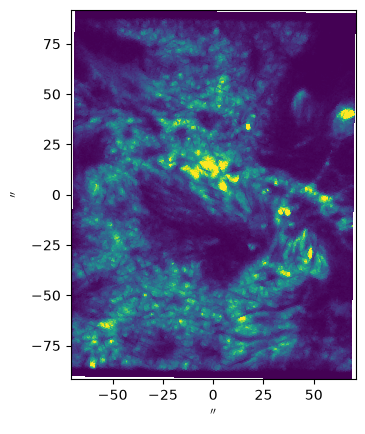

In [32]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots()
    na.plt.pcolormesh(
        smin.inputs.position.x,
        smin.inputs.position.y,
        C=smin.outputs[{axis_channel: 0, scene.axis_wavelength:0 }].value,
        vmin=0,
        vmax=np.percentile(smin.outputs, 99.5).value,
    )
    ax.set_aspect("equal")

In [33]:
mart = ctis.inverters.MartInverter(
    instrument=instrument,
    intermediate=True,
    num_iteration=20,
)

In [34]:
spectrum_avg = scene.outputs.mean((scene.axis_detector_x, scene.axis_detector_y))
spectrum_avg = spectrum_avg / spectrum_avg.sum()

In [35]:
std_OV = esis.flights.f1.spectrum.O_V.width_doppler
v = scene.inputs.velocity.cell_centers(scene.axis_wavelength)
# guess_spectral = np.exp(-np.square(v / std_OV) / 2)
std_OV = 37.5  * 1.5 * u.km / u.s
kappa = 0.2
v0 = 0 * u.km / u.s
guess_spectral = (1 + np.square((v - v0) / std_OV) / kappa)**(-kappa - 1)
guess_spectral = guess_spectral / guess_spectral.sum()

In [36]:
guess_spatial = smin.outputs
# guess_spatial = guess_spatial.broadcast_to(scene.outputs.shape)
guess_spatial = guess_spatial / guess_spatial.sum()
guess_spatial.sum()

ScalarArray(
    ndarray=1. ,
    axes=(),
)

In [37]:
guess_total = backprojected.outputs.sum().to(scene.outputs.unit) / 4
guess_total

ScalarArray(
    ndarray=7.41298642e+09 erg / (Angstrom s sr cm2),
    axes=(),
)

In [38]:
guess = guess_spectral * guess_spatial * guess_total
# guess = spectrum_avg * scene.outputs.sum()

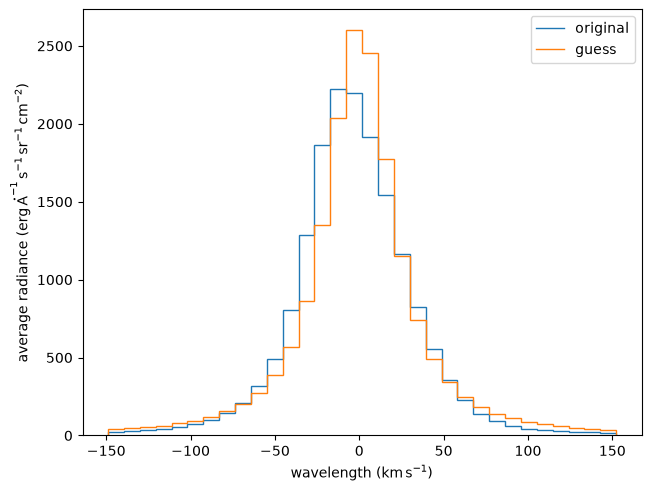

In [39]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    na.plt.stairs(
        scene.inputs.velocity,
        scene.outputs.mean((scene.axis_detector_x, scene.axis_detector_y)),
        ax=ax,
        label="original",
        axis=scene.axis_wavelength,
    )
    na.plt.stairs(
        scene.inputs.velocity,
        guess.mean((scene.axis_detector_x, scene.axis_detector_y)),
        label="guess",
        axis=scene.axis_wavelength,
    )
    ax.set_xlabel(f"wavelength ({ax.get_xlabel()})")
    ax.set_ylabel(f"average radiance ({ax.get_ylabel()})");
    ax.legend()

In [40]:
guess.sum()

ScalarArray(
    ndarray=7.41298642e+09 erg / (Angstrom s sr cm2),
    axes=(),
)

In [41]:
scene.outputs.sum()

ScalarArray(
    ndarray=7.42002096e+09 erg / (Angstrom s sr cm2),
    axes=(),
)

In [42]:
%%time
inversion = mart(images, guess=guess, verbose=True)

i=0


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


merit: ScalarArray(
    ndarray=599.29128415 ,
    axes=(),
)


i=1


merit: ScalarArray(
    ndarray=264.42515065 ,
    axes=(),
)


...

merit: ScalarArray(
    ndarray=1851363.72201749 ,
    axes=(),
)


i=19


merit: ScalarArray(
    ndarray=4312350.70646956 ,
    axes=(),
)


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/ctis/inverters/_iterative/_mart/_mart.py:167: UserWarning: Max number of iterations (20) exceeded.
  warnings.warn(message)


CPU times: user 6min 24s, sys: 11 s, total: 6min 35s
Wall time: 1min 19s


In [43]:
axis_iter = inversion.inverter.axis_iteration

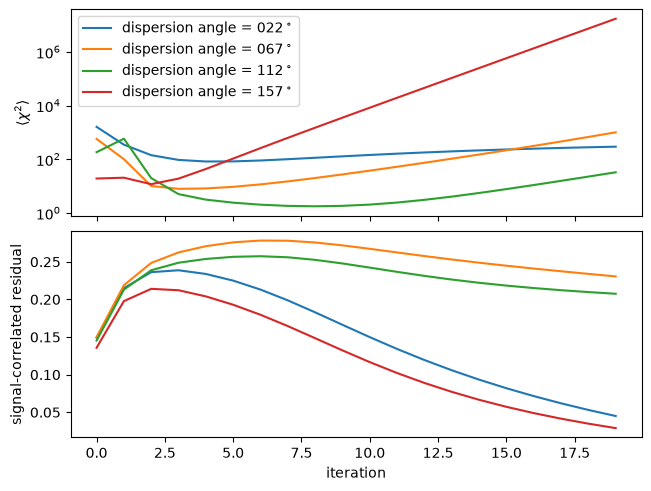

In [44]:
fig, ax = plt.subplots(
    nrows=2,
    sharex=True,
    constrained_layout=True,
)
na.plt.plot(
    inversion.iteration,
    inversion.mean_chi_squared,
    ax=ax[0],
    axis=axis_iter,
    label=channel,
)
na.plt.plot(
    inversion.iteration,
    inversion.correlation_residual,
    ax=ax[1],
    axis=axis_iter,
    label=channel,
)
ax[0].set_ylabel(r"$\langle \chi^2 \rangle$")
ax[1].set_xlabel("iteration")
ax[1].set_ylabel("signal-correlated residual")
ax[0].set_yscale("log")
ax[0].legend();

In [45]:
solution = inversion.solution

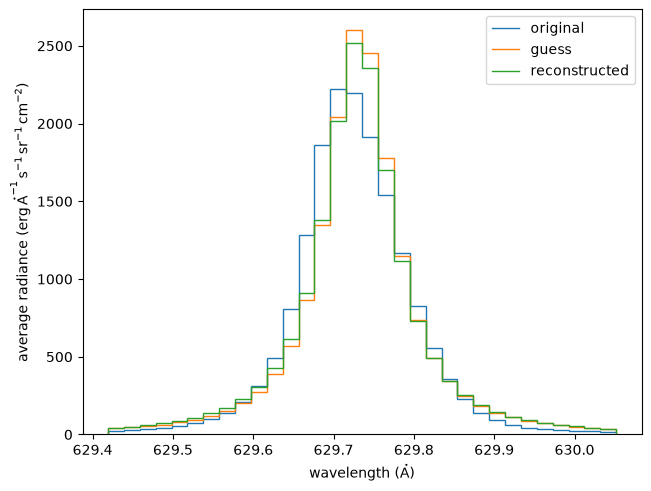

In [46]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    na.plt.stairs(
        scene.inputs.wavelength,
        scene.outputs.mean((scene.axis_detector_x, scene.axis_detector_y)),
        ax=ax,
        label="original",
    )
    na.plt.stairs(
        scene.inputs.wavelength,
        guess.mean((scene.axis_detector_x, scene.axis_detector_y)),
        label="guess",
        axis=scene.axis_wavelength,
    )
    na.plt.stairs(
        solution.inputs.wavelength,
        solution.outputs.mean((scene.axis_detector_x, scene.axis_detector_y)),
        ax=ax,
        label="reconstructed",
    )
    ax.set_xlabel(f"wavelength ({ax.get_xlabel()})")
    # ax2.set_xlabel(f"wavelength ({ax2.get_xlabel()})")
    ax.set_ylabel(f"average radiance ({ax.get_ylabel()})")
    ax.legend()

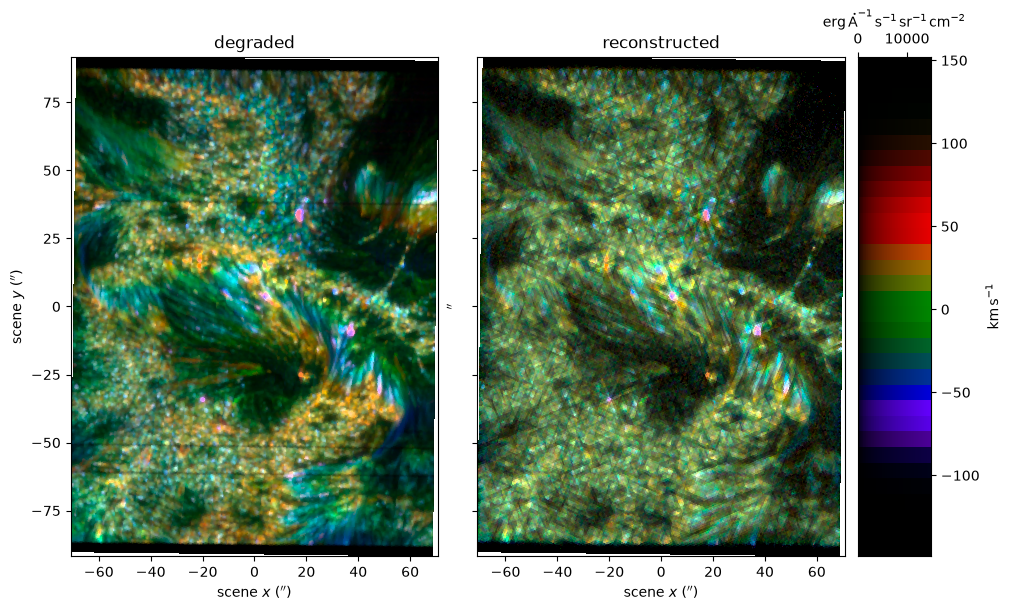

In [47]:
with astropy.visualization.quantity_support():
    fig, axs = plt.subplots(
        ncols=3,
        gridspec_kw=dict(width_ratios=[.5, .5, .1]),
        constrained_layout=True,
        figsize=(10, 6),
    )
    ax1, ax2, cax = axs
    ax2.set_yticklabels([])
    vmin = np.nanpercentile(
        a=scene.outputs,
        q=0.5,
        axis=(scene.axis_detector_x, scene.axis_detector_y),
    )
    vmax = np.nanpercentile(
        a=scene.outputs,
        q=99.5,
        axis=(scene.axis_detector_x, scene.axis_detector_y),
    )
    wavelength_min=-100 * u.km / u.s,
    wavelength_max=+100 * u.km / u.s,
    na.plt.rgbmesh(
        scene.inputs.velocity.cell_centers(scene.axis_wavelength),
        scene.inputs.position.x,
        scene.inputs.position.y,
        C=scene_degraded.outputs,
        axis_wavelength=scene.axis_wavelength,
        ax=ax1,
        vmin=vmin,
        vmax=vmax,
        wavelength_min=-100 * u.km / u.s,
        wavelength_max=+100 * u.km / u.s,
    )
    colorbar = na.plt.rgbmesh(
        scene.inputs.velocity.cell_centers(scene.axis_wavelength),
        scene.inputs.position.x,
        scene.inputs.position.y,
        C=solution.outputs,
        axis_wavelength=scene.axis_wavelength,
        ax=ax2,
        vmin=vmin,
        vmax=vmax,
        wavelength_min=-100 * u.km / u.s,
        wavelength_max=+100 * u.km / u.s,
    )
    na.plt.pcolormesh(
        C=colorbar,
        axis_rgb=scene.axis_wavelength,
        ax=cax,
    )
    ax1.set_title("degraded")
    ax2.set_title("reconstructed")
    unit_x = scene.inputs.position.x.unit
    unit_y = scene.inputs.position.y.unit
    ax1.set_xlabel(f"scene $x$ ({unit_x:latex_inline})")
    ax2.set_xlabel(f"scene $x$ ({unit_x:latex_inline})")
    ax1.set_ylabel(f"scene $y$ ({unit_y:latex_inline})")
    cax.xaxis.set_ticks_position("top")
    cax.xaxis.set_label_position("top")
    cax.yaxis.tick_right()
    cax.yaxis.set_label_position("right")

In [48]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(
        ncols=2,
        constrained_layout=True,
        sharex=True,
        sharey=True,
        figsize=(6, 5),
    )
    i = {scene.axis_detector_x: 210}
    vmax = scene_degraded.outputs.percentile(99.9).ndarray.value
    norm = matplotlib.colors.PowerNorm(gamma=0.5, vmin=0, vmax=vmax)
    na.plt.pcolormesh(
        scene.inputs.velocity[{scene.axis_detector_x: 0, scene.axis_detector_y: 0}],
        scene.inputs.position.y[i],
        C=scene_degraded.outputs[i].value,
        ax=ax[0],
        norm=norm,
    )
    ani = na.plt.pcolormovie(
        inversion.iteration,
        scene.inputs.velocity[{scene.axis_detector_x: 0, scene.axis_detector_y: 0}],
        inversion.solutions.inputs.position.y[i],
        C=inversion.solutions.outputs[i].to_value(scene_degraded.outputs.unit),
        ax=ax[1],
        axis_time=inversion.inverter.axis_iteration,
        norm=norm,
    )
    ax[0].set_title("original")
    ax[1].set_title("reconstruction")

result = ani.to_jshtml(fps=10)
result = IPython.display.HTML(result)

ani.save("mart-iris-spectra.gif", dpi=200, fps=30)

plt.close(ani._fig)

result

2026-07-08 20:22:09 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


2026-07-08 20:22:15 - matplotlib.animation - WARNING: MovieWriter ffmpeg unavailable; using Pillow instead.


2026-07-08 20:22:15 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.PillowWriter'>


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/named_arrays/_scalars/scalars.py:596: RuntimeWarning: invalid value encountered in divide
  result_ndarray = getattr(function, method)(*inputs_ndarray, **kwargs_ndarray)


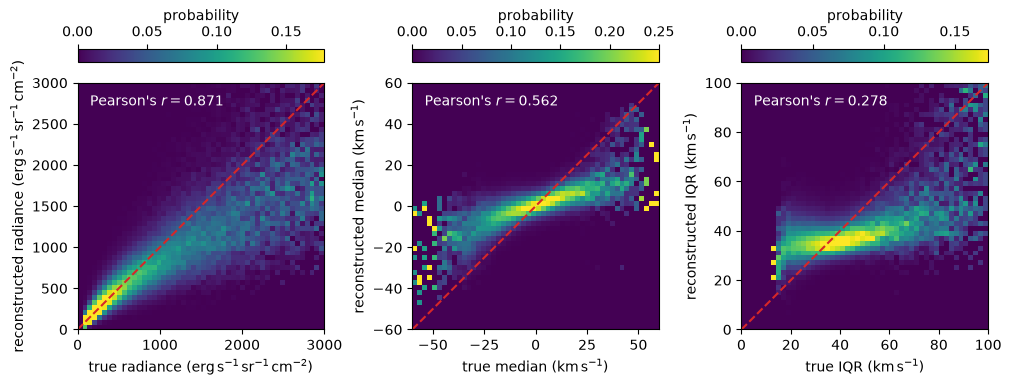

In [49]:
inversion.plot_moments(
    truth=scene, 
    axis=scene.axis_wavelength,
    range_radiance=[0, 3e3] * u.erg / u.s / u.sr / u.cm**2,
    range_median=[-60, 60] * u.km / u.s,
    range_iqr=[0, 100] * u.km / u.s,
    percentile_radiance=25,
);

In [50]:
%%time
predictions = instrument.image(solution, noise=False)

CPU times: user 10.8 s, sys: 102 ms, total: 10.9 s
Wall time: 1.6 s


In [51]:
residual = images - predictions

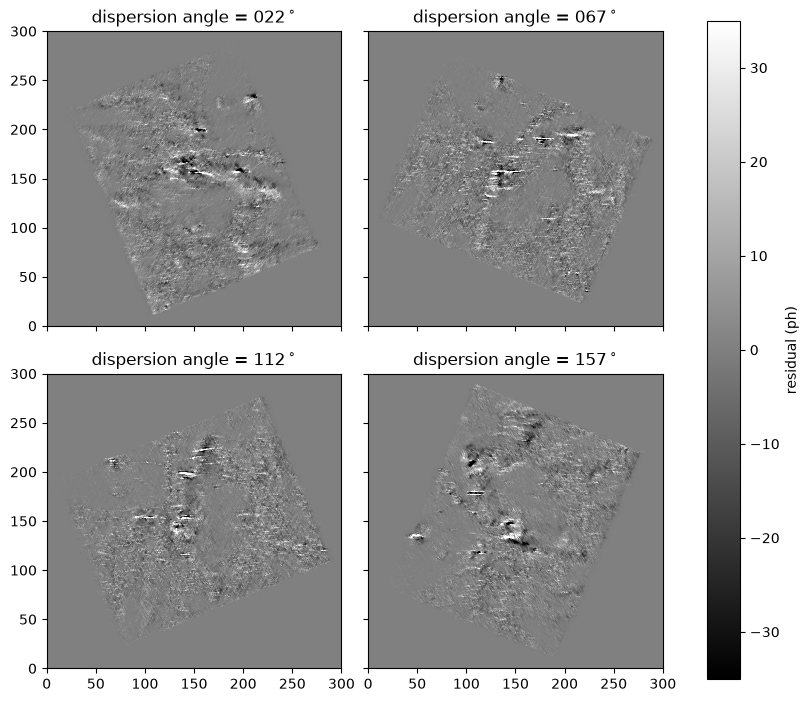

In [52]:
fig, ax = na.plt.subplots(
    axis_rows="rows",
    axis_cols="cols",
    nrows=2,
    ncols=2,
    constrained_layout=True,
    figsize=(8,7),
    sharex=True,
    sharey=True,
    origin="upper",
)
ax = ax.reshape(dict(channel=-1))
vmin = -35
vmax = +35
img = na.plt.pcolormesh(
    residual.inputs.position.x,
    residual.inputs.position.y,
    C=residual.outputs.value,
    ax=ax,
    vmin=vmin,
    vmax=vmax,
    cmap="gray",
)
na.plt.set_title
na.plt.set_aspect("equal", ax=ax)
plt.colorbar(
    ax=ax.ndarray,
    mappable=img.ndarray[0],
    label=f"residual ({residual.outputs.unit:latex_inline})",
);
na.plt.set_title(channel, ax=ax);

In [53]:
float(scipy.stats.spearmanr(predictions.outputs.ndarray.reshape(-1), residual.outputs.ndarray.reshape(-1)).statistic)

-0.06068839474909354

In [54]:
float(scipy.stats.pearsonr(predictions.outputs.ndarray.reshape(-1), residual.outputs.ndarray.reshape(-1)).statistic)

0.12736842189878808

In [55]:
images_perfect = instrument.image(scene, noise=False)

In [56]:
inversion.inverter.mean_chi_squared(
    images.outputs,
    images_perfect.outputs,
)

ScalarArray(
    ndarray=[0.98277884, 1.07684393, 0.97616402, 1.00012152] ,
    axes=('channel',),
)

In [57]:
inversion.inverter.correlation_residual(
    images.outputs,
    predictions.outputs,
).ptp()

ScalarArray(
    ndarray=0.20160991 ,
    axes=(),
)

In [58]:
# with astropy.visualization.quantity_support():
#     fig, axs = plt.subplots(
#         ncols=3,
#         gridspec_kw=dict(width_ratios=[.5, .5, .1]),
#         constrained_layout=True,
#         figsize=(10, 6),
#     )
#     ax1, ax2, cax = axs
#     ax2.set_yticklabels([])
#     vmax = np.nanpercentile(
#         a=scene.outputs,
#         q=99.5,
        
#         axis=(scene.axis_detector_x, scene.axis_detector_y),
#     )

#     na.plt.rgbmesh(
#         C=scene_degraded,
#         axis_wavelength="wavelength",
#         ax=ax1,
#         vmin=0,
#         vmax=vmax,
#     )
#     label = "iteration = " + inversion.iteration.to_string_array("%d")
#     chisq_str = r"$\langle \chi^2 \rangle$"
#     label = label + f"\n{chisq_str} = " + inversion.mean_chi_squared.mean("channel").to_string_array("%.03f")
#     ani, colorbar = na.plt.rgbmovie(
#         label,
#         scene.velocity_doppler,
#         scene.inputs.position.x,
#         scene.inputs.position.y,
#         C=inversion.solutions.outputs,
#         axis_time=inversion.inverter.axis_iteration,
#         axis_wavelength="wavelength",
#         ax=ax2,
#         vmin=0,
#         vmax=vmax,
#     )
#     na.plt.pcolormesh(
#         C=colorbar,
#         axis_rgb="wavelength",
#         ax=cax,
#     )
#     ax1.set_title("original")
#     ax2.set_title("reconstructed")
#     unit_x = scene.inputs.position.x.unit
#     unit_y = scene.inputs.position.y.unit
#     ax1.set_xlabel(f"scene $x$ ({unit_x:latex_inline})")
#     ax2.set_xlabel(f"scene $x$ ({unit_x:latex_inline})")
#     ax1.set_ylabel(f"scene $y$ ({unit_y:latex_inline})")
#     cax.xaxis.set_ticks_position("top")
#     cax.xaxis.set_label_position("top")
#     cax.yaxis.tick_right()
#     cax.yaxis.set_label_position("right")

# result = ani.to_jshtml(fps=30)
# result = IPython.display.HTML(result)

# ani.save("mart-iris-rgb.mp4")

# plt.close(ani._fig)

# result

 - mulitply counts by 10 to see how it changes the results
 - smooth the outputs before taking the residual (and computing the moments)
 - negative correlation coefficient implies that we went a little too far (crossed zero)

$d \chi = \frac{d' - d}{\sqrt{d}}$ contribution of the residual to the total chi square (SNR-weighted residual)